# Week 8: Advanced ML Techniques — Model Building & Comparison
### AI/ML Fellowship — GDGOC ATK
##   Table of Contents
1. Imports & Setup
2. Dataset Loading & EDA
3. Data Preprocessing
4. Decision Tree Classifier
5. Random Forest Regressor
6. SVM — Classification & Regression
7. Boosting — AdaBoost & Gradient Boosting
8. Model Stacking
9. Housing Price Prediction
10. ML Model Comparison Report
11. Conclusion

In [1]:
# Imports & Setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, classification_report,
                             confusion_matrix)

# Tree-Based
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                               AdaBoostClassifier, GradientBoostingRegressor,
                               StackingRegressor)

# SVM
from sklearn.svm import SVC, SVR

# Linear
from sklearn.linear_model import LinearRegression, Ridge, Lasso

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")

print(" All libraries imported successfully!")

 All libraries imported successfully!


## 1. Dataset Loading & Exploratory Data Analysis (EDA)
We use two datasets:
- **California Housing** → for regression tasks (housing price prediction)
- **Breast Cancer** → for classification tasks (SVM, Decision Tree, AdaBoost)

In [2]:
# LOAD DATASETS

# --- Regression Dataset ---
housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
df_housing['Price'] = housing.target

print(" Housing Dataset Shape:", df_housing.shape)
print(df_housing.describe().round(2))

# --- Classification Dataset ---
cancer = load_breast_cancer()
df_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df_cancer['target'] = cancer.target

print("\n Cancer Dataset Shape:", df_cancer.shape)
print(df_cancer['target'].value_counts())

 Housing Dataset Shape: (20640, 9)
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude     Price  
count  20640.00   20640.00  20640.00  
mean      35.63    -119.57      2.07  
std        2.14       2.00      1.15  
min       32.54    -124.35      0.15  
25%       33.93    -121.80      1.20  
50%       34.26    -118.49      1.80  
75%       37.71    -118.01      2.65  
max 

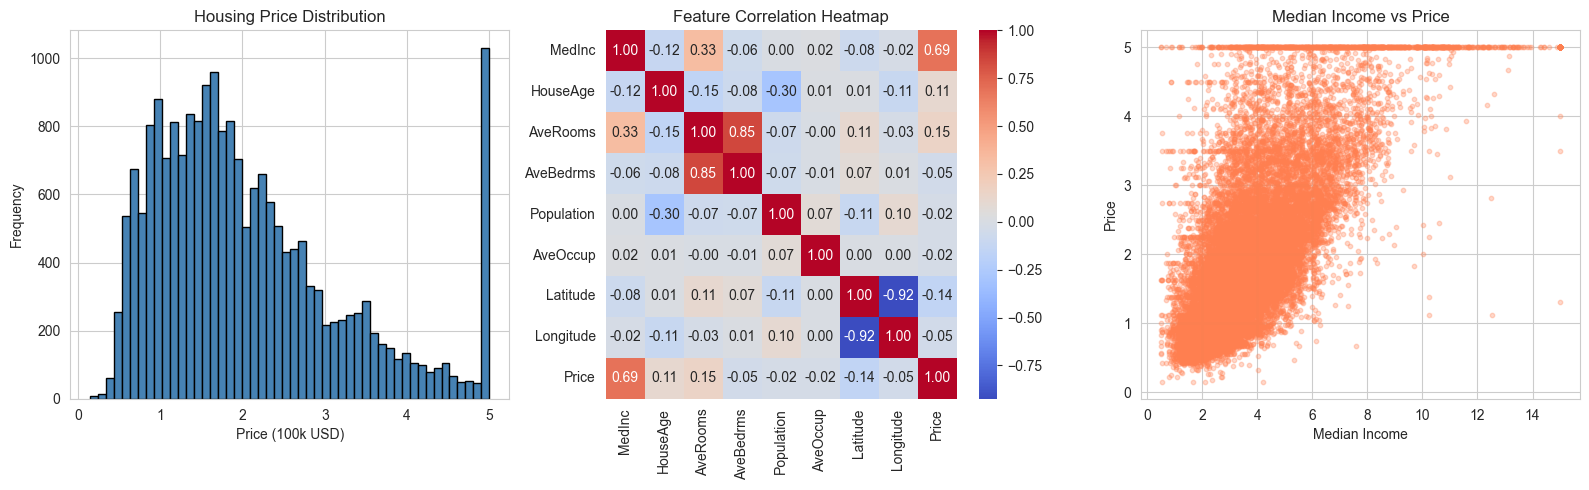

In [3]:
# EDA PLOTS

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Price distribution
axes[0].hist(df_housing['Price'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title("Housing Price Distribution")
axes[0].set_xlabel("Price (100k USD)")
axes[0].set_ylabel("Frequency")

# Correlation heatmap
corr = df_housing.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1])
axes[1].set_title("Feature Correlation Heatmap")

# Top features vs price
axes[2].scatter(df_housing['MedInc'], df_housing['Price'],
                alpha=0.3, color='coral', s=10)
axes[2].set_title("Median Income vs Price")
axes[2].set_xlabel("Median Income")
axes[2].set_ylabel("Price")

plt.tight_layout()
plt.show()

## 2. Data Preprocessing
Splitting data into train/test sets and scaling features.

In [4]:
# PREPROCESSING
# --- Housing (Regression) ---
X_house = df_housing.drop('Price', axis=1)
y_house = df_housing['Price']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_house, y_house, test_size=0.2, random_state=42)

scaler_h = StandardScaler()
X_train_h_sc = scaler_h.fit_transform(X_train_h)
X_test_h_sc = scaler_h.transform(X_test_h)

# --- Cancer (Classification) ---
X_canc = df_cancer.drop('target', axis=1)
y_canc = df_cancer['target']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_canc, y_canc, test_size=0.2, random_state=42)

scaler_c = StandardScaler()
X_train_c_sc = scaler_c.fit_transform(X_train_c)
X_test_c_sc = scaler_c.transform(X_test_c)

print(" Preprocessing complete!")
print(f"Housing  → Train: {X_train_h.shape}, Test: {X_test_h.shape}")
print(f"Cancer   → Train: {X_train_c.shape}, Test: {X_test_c.shape}")

 Preprocessing complete!
Housing  → Train: (16512, 8), Test: (4128, 8)
Cancer   → Train: (455, 30), Test: (114, 30)


## 3. Decision Tree Classifier
Decision Trees split data based on feature thresholds to maximize information gain.
We apply it on the Breast Cancer dataset and tune max_depth.

  Decision Tree Accuracy: 0.9474

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



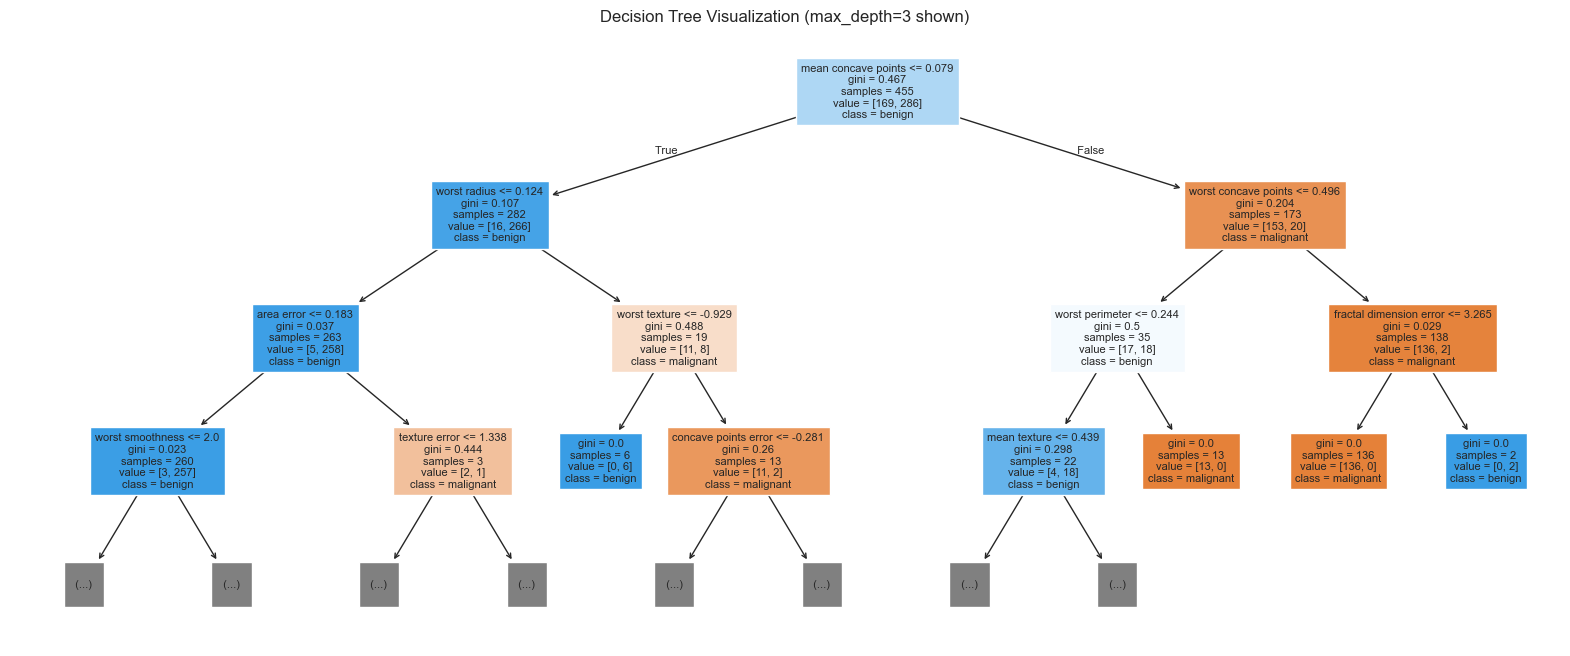

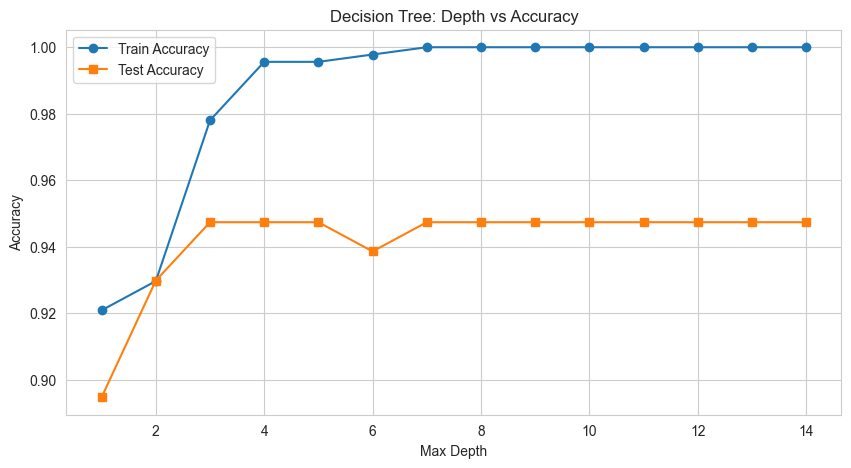

In [5]:
# DECISION TREE CLASSIFIER

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_c_sc, y_train_c)
y_pred_dt = dt.predict(X_test_c_sc)

dt_acc = accuracy_score(y_test_c, y_pred_dt)
print(f"  Decision Tree Accuracy: {dt_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_dt,
      target_names=cancer.target_names))

# Plot tree
plt.figure(figsize=(20, 8))
plot_tree(dt, max_depth=3, feature_names=cancer.feature_names,
          class_names=cancer.target_names, filled=True, fontsize=8)
plt.title("Decision Tree Visualization (max_depth=3 shown)")
plt.show()

# Hyperparameter tuning
depths = range(1, 15)
train_scores, test_scores = [], []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train_c_sc, y_train_c)
    train_scores.append(accuracy_score(y_train_c, clf.predict(X_train_c_sc)))
    test_scores.append(accuracy_score(y_test_c, clf.predict(X_test_c_sc)))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, label='Train Accuracy', marker='o')
plt.plot(depths, test_scores, label='Test Accuracy', marker='s')
plt.title("Decision Tree: Depth vs Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 4. Random Forest Regressor
Random Forest builds multiple decision trees and averages their predictions.
It reduces overfitting compared to a single decision tree.

  Random Forest → MSE: 0.2552 | R²: 0.8053


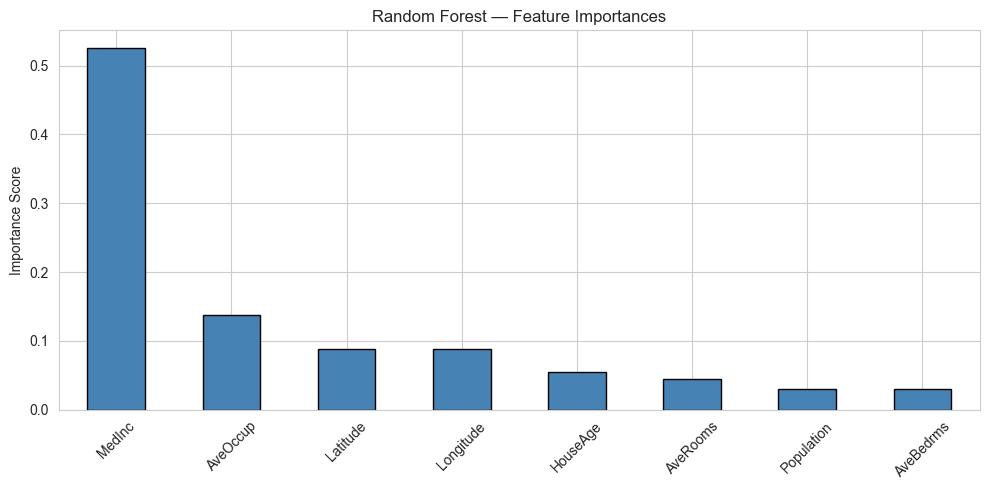

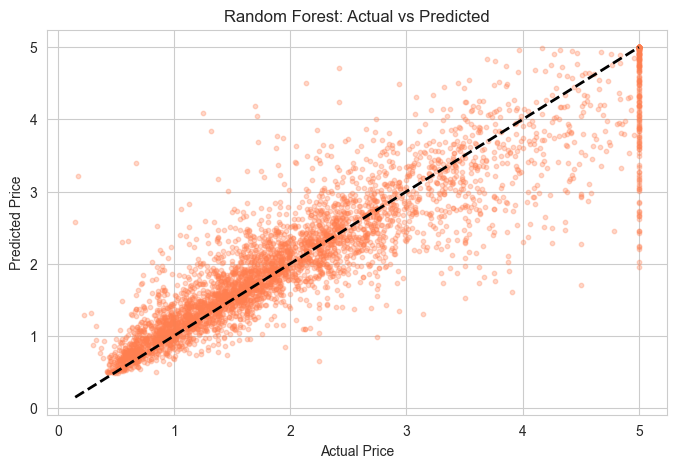

In [6]:
# RANDOM FOREST REGRESSOR

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_h_sc, y_train_h)
y_pred_rf = rf.predict(X_test_h_sc)

rf_mse = mean_squared_error(y_test_h, y_pred_rf)
rf_r2  = r2_score(y_test_h, y_pred_rf)
print(f"  Random Forest → MSE: {rf_mse:.4f} | R²: {rf_r2:.4f}")

# Feature Importance
feat_imp = pd.Series(rf.feature_importances_,
                     index=housing.feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Random Forest — Feature Importances")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test_h, y_pred_rf, alpha=0.3, color='coral', s=10)
plt.plot([y_test_h.min(), y_test_h.max()],
         [y_test_h.min(), y_test_h.max()], 'k--', lw=2)
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

## 5. SVM — Classification & Regression
Support Vector Machines find the optimal hyperplane that maximizes margin between classes.
- **SVC** → Classification on Cancer dataset
- **SVR** → Regression on Housing dataset

 SVM Classifier Accuracy: 0.9825
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        43
      benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



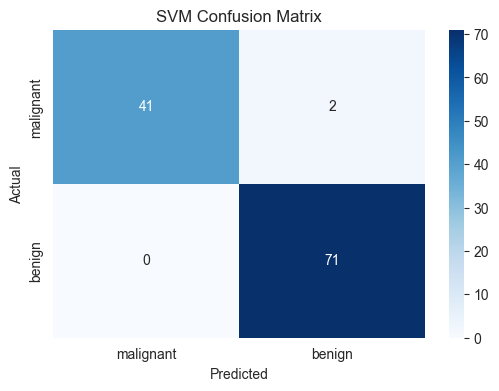


 SVR → MSE: 0.3738 | R²: 0.7244


In [7]:
# SVM CLASSIFICATION & REGRESSION
# --- SVC ---
svc = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svc.fit(X_train_c_sc, y_train_c)
y_pred_svc = svc.predict(X_test_c_sc)

svc_acc = accuracy_score(y_test_c, y_pred_svc)
print(f" SVM Classifier Accuracy: {svc_acc:.4f}")
print(classification_report(y_test_c, y_pred_svc,
      target_names=cancer.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_svc)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.title("SVM Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# --- SVR ---
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr.fit(X_train_h_sc[:2000], y_train_h[:2000])  # subset for speed
y_pred_svr = svr.predict(X_test_h_sc[:500])

svr_mse = mean_squared_error(y_test_h[:500], y_pred_svr)
svr_r2  = r2_score(y_test_h[:500], y_pred_svr)
print(f"\n SVR → MSE: {svr_mse:.4f} | R²: {svr_r2:.4f}")

## 6. Boosting — AdaBoost & Gradient Boosting
Boosting builds models sequentially, each correcting errors of the previous one.
- **AdaBoost** → focuses on misclassified samples
- **Gradient Boosting** → minimizes loss using gradient descent

  AdaBoost Accuracy: 0.9737
  Gradient Boosting → MSE: 0.2595 | R²: 0.8020


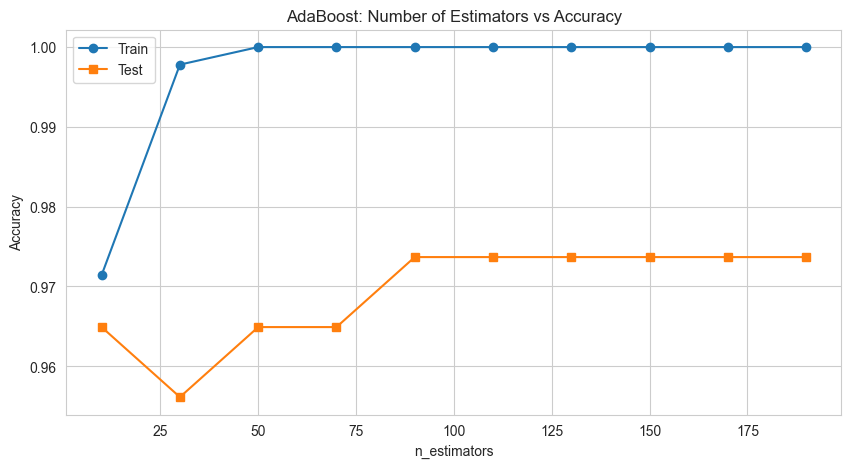

In [8]:
# ADABOOST & GRADIENT BOOSTING
# --- AdaBoost Classifier ---
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train_c_sc, y_train_c)
y_pred_ada = ada.predict(X_test_c_sc)

ada_acc = accuracy_score(y_test_c, y_pred_ada)
print(f"  AdaBoost Accuracy: {ada_acc:.4f}")

# --- Gradient Boosting Regressor ---
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                max_depth=4, random_state=42)
gb.fit(X_train_h_sc, y_train_h)
y_pred_gb = gb.predict(X_test_h_sc)

gb_mse = mean_squared_error(y_test_h, y_pred_gb)
gb_r2  = r2_score(y_test_h, y_pred_gb)
print(f"  Gradient Boosting → MSE: {gb_mse:.4f} | R²: {gb_r2:.4f}")

# Learning curve for AdaBoost
ada_train_scores = []
ada_test_scores  = []
estimator_range = range(10, 200, 20)

for n in estimator_range:
    clf = AdaBoostClassifier(n_estimators=n, random_state=42)
    clf.fit(X_train_c_sc, y_train_c)
    ada_train_scores.append(accuracy_score(y_train_c, clf.predict(X_train_c_sc)))
    ada_test_scores.append(accuracy_score(y_test_c, clf.predict(X_test_c_sc)))

plt.figure(figsize=(10, 5))
plt.plot(estimator_range, ada_train_scores, label='Train', marker='o')
plt.plot(estimator_range, ada_test_scores,  label='Test',  marker='s')
plt.title("AdaBoost: Number of Estimators vs Accuracy")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 7. Model Stacking
Stacking combines multiple base models and uses a meta-learner to make final predictions.
Base models: Linear Regression, Random Forest, Gradient Boosting
Meta-learner: Ridge Regression

In [9]:
# MODEL STACKING
estimators = [
    ('lr',  LinearRegression()),
    ('rf',  RandomForestRegressor(n_estimators=50, random_state=42)),
    ('gb',  GradientBoostingRegressor(n_estimators=50, random_state=42))
]

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge()
)

stacking_model.fit(X_train_h_sc, y_train_h)
y_pred_stack = stacking_model.predict(X_test_h_sc)

stack_mse = mean_squared_error(y_test_h, y_pred_stack)
stack_r2  = r2_score(y_test_h, y_pred_stack)
print(f" Stacking Model → MSE: {stack_mse:.4f} | R²: {stack_r2:.4f}")

 Stacking Model → MSE: 0.2575 | R²: 0.8035


## 8. Housing Price Prediction — Linear Regression vs Multiple Models
As per assignment: Build a Linear Regression model using scikit-learn
and compare it against other models for housing price prediction.

  Linear Regression → MSE: 0.5559 | R²: 0.5758
  Ridge Regression  → MSE: 0.5559 | R²: 0.5758
  Lasso Regression  → MSE: 0.6796 | R²: 0.4814


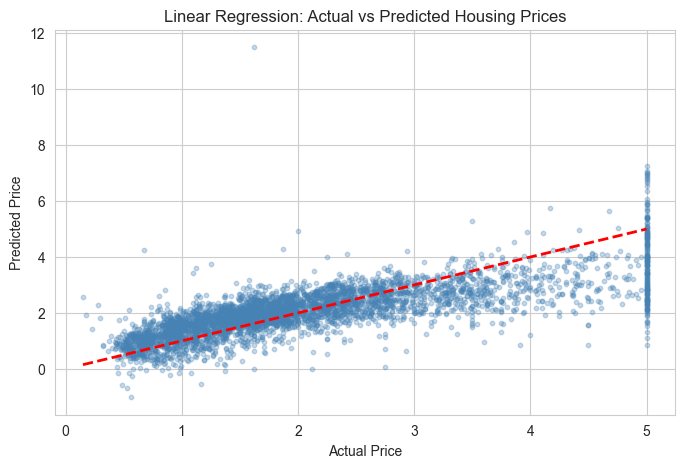

In [10]:
# HOUSING PRICE PREDICTION — LINEAR REGRESSION 
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_h_sc, y_train_h)
y_pred_lr = lr.predict(X_test_h_sc)

lr_mse = mean_squared_error(y_test_h, y_pred_lr)
lr_r2  = r2_score(y_test_h, y_pred_lr)
print(f"  Linear Regression → MSE: {lr_mse:.4f} | R²: {lr_r2:.4f}")

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_h_sc, y_train_h)
y_pred_ridge = ridge.predict(X_test_h_sc)

ridge_mse = mean_squared_error(y_test_h, y_pred_ridge)
ridge_r2  = r2_score(y_test_h, y_pred_ridge)
print(f"  Ridge Regression  → MSE: {ridge_mse:.4f} | R²: {ridge_r2:.4f}")

# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_h_sc, y_train_h)
y_pred_lasso = lasso.predict(X_test_h_sc)

lasso_mse = mean_squared_error(y_test_h, y_pred_lasso)
lasso_r2  = r2_score(y_test_h, y_pred_lasso)
print(f"  Lasso Regression  → MSE: {lasso_mse:.4f} | R²: {lasso_r2:.4f}")

# Actual vs Predicted — Linear Regression
plt.figure(figsize=(8, 5))
plt.scatter(y_test_h, y_pred_lr, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test_h.min(), y_test_h.max()],
         [y_test_h.min(), y_test_h.max()], 'r--', lw=2)
plt.title("Linear Regression: Actual vs Predicted Housing Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

## 9.  ML Model Comparison Report
Comparing all models on the Housing Price Prediction task.
Metrics: MSE (lower is better), R² Score (higher is better)

       ML MODEL COMPARISON REPORT
                      MSE      R2
Random Forest      0.2552  0.8053
Stacking Model     0.2575  0.8035
Gradient Boosting  0.2595  0.8020
SVR                0.3738  0.7244
Ridge Regression   0.5559  0.5758
Linear Regression  0.5559  0.5758
Lasso Regression   0.6796  0.4814

  Best Model: Random Forest (R²=0.8053)


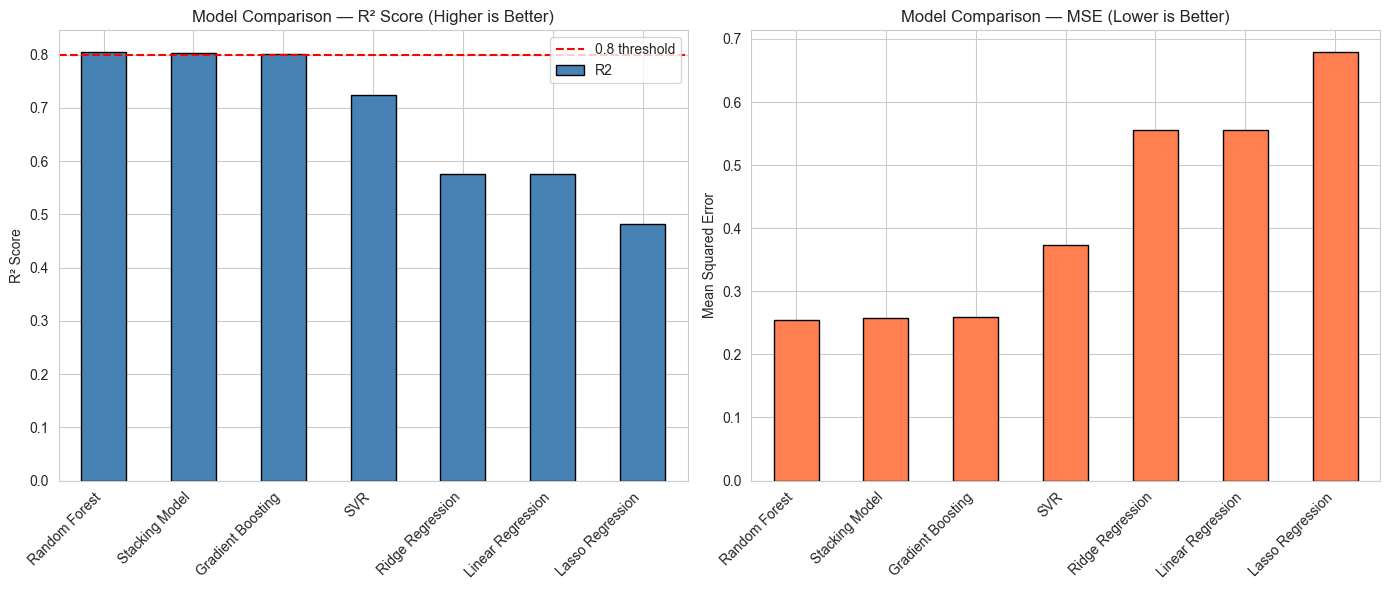

In [12]:
# ML MODEL COMPARISON REPORT

results = {
    'Linear Regression':    {'MSE': lr_mse,    'R2': lr_r2},
    'Ridge Regression':     {'MSE': ridge_mse, 'R2': ridge_r2},
    'Lasso Regression':     {'MSE': lasso_mse, 'R2': lasso_r2},
    'Random Forest':        {'MSE': rf_mse,    'R2': rf_r2},
    'Gradient Boosting':    {'MSE': gb_mse,    'R2': gb_r2},
    'SVR':                  {'MSE': svr_mse,   'R2': svr_r2},
    'Stacking Model':       {'MSE': stack_mse, 'R2': stack_r2},
}

df_results = pd.DataFrame(results).T.sort_values('R2', ascending=False)
df_results = df_results.round(4)

print("=" * 50)
print("       ML MODEL COMPARISON REPORT")
print("=" * 50)
print(df_results.to_string())
print("=" * 50)
print(f"\n  Best Model: {df_results['R2'].idxmax()} (R²={df_results['R2'].max():.4f})")

# Bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_results['R2'].plot(kind='bar', ax=axes[0],
                      color='steelblue', edgecolor='black')
axes[0].set_title("Model Comparison — R² Score (Higher is Better)")
axes[0].set_ylabel("R² Score")
axes[0].set_xticklabels(df_results.index, rotation=45, ha='right')
axes[0].axhline(y=0.8, color='red', linestyle='--', label='0.8 threshold')
axes[0].legend()

df_results['MSE'].plot(kind='bar', ax=axes[1],
                       color='coral', edgecolor='black')
axes[1].set_title("Model Comparison — MSE (Lower is Better)")
axes[1].set_ylabel("Mean Squared Error")
axes[1].set_xticklabels(df_results.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

---
## 10. Conclusion

| Model | Type | Best For |
|---|---|---|
| Linear Regression | Regression | Simple, interpretable baseline |
| Ridge / Lasso | Regression | When features are correlated / sparse |
| Decision Tree | Classification | Interpretable, handles non-linearity |
| Random Forest | Both | High accuracy, handles overfitting |
| SVM | Both | High-dimensional, small datasets |
| AdaBoost | Classification | Boosting weak learners |
| Gradient Boosting | Regression | Often best performing regressor |
| Stacking | Both | Combines strengths of multiple models |

**Key Findings:**
- Tree-based ensemble models (Random Forest, Gradient Boosting) outperform Linear Regression on housing prices
- SVMs work well for classification but are slow on large datasets
- Stacking combines model strengths for best overall performance
- Linear Regression remains a strong, interpretable baseline